# ENSO -> Hadley -> Jet: A Latitude-Height Teleconnection Atlas

**Four-scenario visualization of how equatorial sea-surface temperature anomalies project onto the mid-latitude winter jet.**

Bjerknes Diagnostic Lab - portfolio module. Author: Shun-Chan Tsai.

---

## The one question this figure answers

> **Why does a warm equatorial Pacific (El Nino) produce a strong, organized mid-latitude winter jet (a "high-index" winter), while other states do not?**

The answer is a causal chain, and each panel shows one link:

$$\underbrace{\text{Warm equatorial SST}}_{\text{Panel 1}} \;\longrightarrow\; \underbrace{\text{stronger Hadley overturning}}_{\text{Panel 2}} \;\longrightarrow\; \underbrace{\text{poleward angular-momentum transport}}_{\text{Panel 3 arrows}} \;\longrightarrow\; \underbrace{\text{convergence at }\sim 30^\circ\text{N}}_{\text{Panel 3 marker}} \;\longrightarrow\; \underbrace{\text{strong subtropical jet}}_{\text{Panel 3 shading}}$$

### Why angular momentum is the hinge

Air sitting at the equator is already moving **eastward in an inertial frame** (relative to the stars, not the ground) at roughly $\Omega a \approx 465\ \mathrm{m\,s^{-1}}$ simply because Earth's surface spins fastest there. Its **absolute angular momentum** is

$$M = \underbrace{u}_{\text{wind}} + \underbrace{\Omega a \cos\phi}_{\text{planetary}}\,,$$

where $u$ is the wind relative to the ground (what you measure) and $\Omega a\cos\phi$ is how fast the ground itself is moving eastward. At the equator this planetary term dominates; an air parcel at rest relative to the ground still carries enormous eastward angular momentum just by sitting there.

**The two branches of the Hadley cell have opposite winds relative to the ground:**
- **Surface branch** (air moving equatorward): it can't keep up with the faster-spinning equator beneath it → **easterly trade winds** (relative wind, westward). This is what you see with a weather station.
- **Upper branch** (air moving poleward): it outruns the slowly-spinning high latitudes beneath it → **westerly winds** (relative wind, eastward).

Both are the *same air* conserving its eastward angular momentum $M$. The Hadley cell lifts equatorial air (high $M$) and carries it poleward. As it moves toward the axis of rotation, conservation of $M$ forces its relative eastward wind $u$ to **increase** — the spinning-skater effect. By $\sim 30^\circ$N that equatorial angular momentum has been concentrated into the **subtropical jet** (a westerly wind relative to the ground). A stronger Hadley cell pumps more momentum poleward, so the jet is stronger and the winter is high-index. **The jet is concentrated equatorial angular momentum.**

---

## Two noteworthy points when interpreting figures below

**1. They show the downstream teleconnection, not the equatorial see-saw itself.**
The original Bjerknes see-saw is a *zonal* (east-west / Walker) pressure oscillation along the equator. The figures below, however, are meridional (north-south / Hadley) cross-sections—a deliberate **abstraction**. Rather than tracking the equatorial node position, we instead ask: *how much does this ENSO state strengthen or weaken the meridional overturning?* Each scenario is represented by its *meridional SST structure* and the resulting *downstream* teleconnection into the mid-latitude jet. The figures show the **consequence** (tropical forcing → mid-latitude jet), not the equatorial see-saw itself.

**2. All fields are anomalies relative to ENSO-neutral.**
SST, pressure, circulation, and wind are all departures from a neutral climatology. So:
- El Nino (A): a *negative* surface-pressure anomaly → enhanced overturning → strong transport arrows.
- Uniform warm (B): *no* horizontal pressure-anomaly gradient -> essentially *no* anomalous overturning, despite high SST magnitude.
- La Nina (C, D): a *positive* surface-pressure anomaly → weakened overturning → weak arrows.

> **Scenario B breaks the intuition.** It has the highest SST anomaly (+2.5°C) yet produces the *weakest* teleconnection. Why? No gradient → no pressure-anomaly gradient → no driver. This is why the table of scenarios lists B as producing a "VARIABLE" response despite being warm: magnitude alone does not drive the teleconnection.
---

## How to read the three panels

| Panel | Shows | Encoding |
|---|---|---|
| **1** | Equator-to-pole SST anomaly (the lower-boundary forcing) | red fill = warm, blue fill = cold |
| **2** | Pressure anomaly (physical cause) & Hadley circulation (effect) | **Pressure:** filled contours + black lines; **Circulation:** dark-green arrows for air flow (**length ∝ speed**, fixed Scenario-A reference); dashed lines mark the rising/sinking branches. |
| **3** | Upper troposphere: the jet and its driver | **Shading** = zonal wind (red = westerly jet, white = zero, blue = easterly); **purple arrows** = poleward angular-momentum transport (**length ∝ magnitude**, fixed Scenario-A reference) |

**Display conventions (identical across all four scenarios for honest comparison):**
- SST axis, pressure color range, jet color range, and all arrow scales are identical in A/B/C/D. A pale jet really is a weaker jet.
- **Vertical motion in Panel 2 is visually exaggerated (~6x).** Real vertical velocities are $\sim\mathrm{cm\,s^{-1}}$ against horizontal $\sim\mathrm{m\,s^{-1}}$; without exaggeration the loop would look flat.
- The jet color scale is centered on zero but **asymmetric** (the westerly jet maximum far exceeds the tropical easterlies), so white always means zero wind.

> The same three-panel structure repeats for every scenario. Master Scenario A, then read B/C/D as systematic variations on the parameters.

## How to use this atlas

**Download, run top-to-bottom, and the four `plot_scenario(...)` calls will regenerate every figure.** Tweak any parameter in the `scenarios` dictionary (Cell 7) and the whole atlas updates consistently.

The `scenarios` dict contains six entries for each of A, B, C, D:
- `sst_amp` — peak SST anomaly magnitude (°C)
- `gradient` — boolean; whether to include meridional structure
- `hadley_strength` — amplitude of streamfunction (0.08 to 1.0)
- `momentum_flux` — angular-momentum transport magnitude (0.10 to 1.0)
- `center_lat` — latitude of Hadley descent (28° to 35°N)
- `winter_index` — qualitative outcome (HIGH / VARIABLE / LOW / LOW (chaotic))

The field generators (`gen_sst`, `gen_pressure`, `gen_hadley`, `gen_wind`, `gen_momentum_flux`) each take parameters from the scenarios dict and produce the three panels. Edit the scenarios dict, re-run the `plot_scenario()` cells, and the atlas rebuilds with no other changes needed.

## 1 - Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
print("numpy", np.__version__)

numpy 1.26.4


## 2 - Domain, constants, and fixed display scales

The domain is a meridional slice from the equator to $60^\circ$N and from the surface to 16 km. The following section defines three **tuning parameters** (Z_MID, H_CELL, SCALE_P) that shape the idealized pressure and Hadley fields. These are **not** physical constants — they are chosen to make the figures look pedagogically clear and roughly realistic. The display scales are frozen so the four scenarios can be compared by eye.

In [2]:
# ---- domain ----
lat = np.linspace(0, 60, 160)        # equator -> 60 N
height = np.linspace(0, 16, 130)     # surface -> 16 km
LAT, HEIGHT = np.meshgrid(lat, height)
lat_tick = [0, 15, 30, 45, 60]
height_tick = [0, 4, 8, 12, 16]

# ---- idealised-model constants (tuning parameters, not first-principles) ----
# These are NOT physical constants. They are chosen to make the idealized pressure
# and circulation fields look reasonable and pedagogically clear. In a real GCM,
# these would emerge from solving the full equations of motion and thermodynamics.

Z_MID = 7.0
# km : the height where pressure anomaly is zero (the sign-flip level).
# For warm SST: below Z_MID => low surface pressure (blue); above => high aloft pressure (red).
# Real tropopause sits ~12-16 km at the equator. Z_MID=7 km puts the sign-flip in the
# mid-troposphere, a "reasonable middle" that balances visual clarity with realism.
# Try Z_MID=0 (surface) and you lose the blue region; try Z_MID=16 and the blue dominates.

H_CELL = 14.0
# km : the vertical extent (height) of the Hadley circulation.
# The streamfunction sin(pi*z/H_CELL) ensures zero vertical motion at z=0 (surface)
# and z=H_CELL (top of cell), with maximum at z=H_CELL/2 ~ 7 km.
# Real tropopause: ~15-18 km at equator. H_CELL=14 km keeps the loop below the tropopause
# and ensures it closes naturally. Try H_CELL=20 km and it extends unrealistically into
# the stratosphere; try H_CELL=8 km and the sinking branch gets cramped into the boundary layer.

SCALE_P = 0.6
# hPa per (degC * km) : converts SST anomalies and heights into pressure-anomaly magnitude.
# p(lat,z) = SST(lat) * (z - Z_MID) * SCALE_P
# Real tropical ENSO pressure anomalies are typically ±5-15 hPa.
# SCALE_P=0.6 scales the model into that ballpark for realism and cross-scenario comparability.
# Increase to 1.0 => pressure anomalies double, contours spread, visual "forcing" amplified.
# Decrease to 0.3 => pressure anomalies halve, contours compress, "forcing" dampened.
# This is the most knob-like parameter: tune it to match observations or adjust visual contrast.

# ---- fixed display scales (IDENTICAL across all scenarios) ----
SST_YLIM        = (-2.6, 2.8)
P_VMIN, P_VMAX  = -12.0, 12.0
U_VMIN, U_VCENTER, U_VMAX = -10.0, 0.0, 32.0   # asymmetric, centered at 0
CIRC_QUIVER_SCALE = 4.0     # larger => shorter circulation arrows
MF_QUIVER_SCALE   = 11.0    # larger => shorter momentum-flux arrows
W_DISPLAY_BOOST   = 6.0     # vertical-motion visual exaggeration (Panel 2)
SPEED_REF         = 0.67    # reference circulation speed (Scenario A max) for linewidth

### Understanding Z_MID, H_CELL, and SCALE_P — the visual grammar of the pressure field

**Key caveat upfront:** These are *tuning knobs for pedagogical clarity*, not physical constants. In a real GCM, the pressure field emerges from solving the equations of motion. Here, we *prescribe* a simple algebraic form and choose these three numbers to look clear and ~realistic. That's the entire point of an idealized diagnostic.

| Parameter | Value | Controls | Why this number |
|---|---|---|---|
| **Z_MID** | 7.0 km | Height where pressure anomaly = 0. Warm SST → low pressure below, high pressure above. | Places inversion in mid-troposphere, matching the real boundary-layer / free-troposphere transition. |
| **H_CELL** | 14.0 km | Height where the Hadley loop closes. | Sits below the real tropopause (15–18 km), keeping the circulation realistic and visible. Too high (20 km) bleeds into stratosphere; too low (8 km) cramps the sinking branch. |
| **SCALE_P** | 0.6 hPa/(°C·km) | Magnitude of all pressure anomalies. Real ENSO anomalies are ±5–15 hPa; this scaling matches observations. | Most tunable: increase to 1.0 for bolder contrasts, decrease to 0.3 for subtler plots. Adjust if presenting to different audiences or validating against data. |

**Why these three stay fixed across A/B/C/D:** The reader's eye sees SST-driven differences cascade into circulation and jet differences—not arbitrary-constant artifacts. That's honest design. If all parameters changed simultaneously, you'd lose the ability to isolate what matters.

## Why this framework is worth publishing

A literature scan found **no prior study asking whether the zero isallobar–gradient maximum alignment is structural or regime-dependent.** This atlas answers that question: Is the pressure-node alignment a thermodynamic inevitability, or does it depend on regime (El Niño vs. La Niña, magnitude vs. structure)?

The **A/B/C/D design isolates exactly this:**
- **A (Strong El Niño):** sharp gradient, zero isallobar and maximum align, vigorous Hadley response.
- **B (Basin-wide warm):** warmest SST (+2.5°C), but uniform—*no gradient*, *no driver*, teleconnection collapses.
- **C & D (La Niña):** displaced nodes, sign-reversed forcing, tests alignment under spatial disruption.

**The central finding: it is the gradient, not the magnitude, that drives the teleconnection.** The visualization is the proof.

## 3 - The four scenarios

Each scenario is fully defined by six parameters. The figure's *structure* never changes—only these numbers do.

### What the six parameters control

They fall into three groups that mirror the causal chain:

**The forcing (what you set):**
- **SST anomaly (°C)** — peak equatorial warming/cooling; how far the boundary condition departs from neutral. B is deliberately *warmer* than A, to test whether magnitude alone drives the teleconnection.
- **Meridional gradient (yes/no)** — does the SST anomaly vary with latitude, or is it uniform? This binary decides whether a horizontal pressure-anomaly gradient exists to drive the Hadley cell. B tests the null hypothesis: *does magnitude without structure produce a response?*

**The response (what follows from the forcing):**
- **Hadley strength (0.08–1.0)** — streamfunction amplitude; sets the meridional and vertical velocities. A direct consequence of the pressure gradient.
- **Momentum flux (0.10–1.0)** — poleward angular-momentum transport in the upper branch; sets purple-arrow length in Panel 3. Scales *with* Hadley strength (a stronger cell carries more momentum), but listed separately so one governs the loop (Panel 2) and the other the jet (Panel 3).

**Position and outcome:**
- **Descent latitude (28°–35°N)** — where the sinking branch sits. Small shifts change where the jet concentrates and whether blocking becomes likely.
- **Winter index (HIGH / VARIABLE / LOW)** — *not an input but the predicted outcome.* HIGH = strong, organized, predictable jet; VARIABLE = unpinned, wandering; LOW = weak (suppressed or disrupted).

### The table

The first four columns are *inputs* (model choices); the last is the *output* (predicted winter character):

| | SST anomaly | Meridional gradient | Hadley strength | Momentum flux | Descent lat | Winter index |
|---|---|---|---|---|---|---|
| **A** Strong El Nino | $+2.0$ | **yes** (clean see-saw) | 1.00 | 1.00 | $30^\circ$ | **HIGH** |
| **B** Basin-wide warm | $+2.5$ | **no** (uniform offset) | 0.08 | 0.10 | $35^\circ$ | VARIABLE |
| **C** La Nina (node E) | $-1.8$ | yes | 0.35 | 0.30 | $32^\circ$ | LOW |
| **D** La Nina (node W) | $-2.0$ | yes (disrupted) | 0.30 | 0.15 | $28^\circ$ | LOW (chaotic) |

### Reading each scenario

- **A (Strong El Niño):** warm, sharp gradient, vigorous overturning, intense flux, compact descent → everything *maximum and organized* → **HIGH**.
- **B (Basin-wide warm):** warmest of all (+2.5°C) but *no gradient* → no driver → near-zero circulation, weak momentum flux (0.10, the smallest of the four) → **VARIABLE** (jet unpinned despite high SST).
- **C (La Niña, node E):** cold, weak gradient, suppressed but still organized → **LOW**.
- **D (La Niña, node W):** coldest, *disrupted* gradient, weakest and most compressed cell, descent dragged to 28°N → the momentum flux is modest in *magnitude* (0.15) but spans the *shortest poleward reach* of the four, because the cell is squeezed equatorward → **LOW (chaotic)**—jet expected to meander and block.

> **The takeaway lives in B.** It is the warmest state yet produces the weakest teleconnection—weaker than either La Niña case—because it has no gradient. Section 7 develops this in full; for now, just note the ordering: warmth alone loses to structure.

In [3]:
scenarios = {
    "A": dict(name="Scenario A: Strong El Nino",
              subtitle="Zero isallobar coincides with gradient maximum (strong see-saw)",
              sst_amp=2.0, gradient=True, sst_width=20, center_lat=5,
              hadley=1.0, mf=1.0, descent_lat=30, response="HIGH"),
    "B": dict(name="Scenario B: El Nino (Basin-Wide Offset)",
              subtitle="No zero isallobar - uniform warming overrides the see-saw",
              sst_amp=2.5, gradient=False, sst_width=60, center_lat=5,
              hadley=0.08, mf=0.10, descent_lat=35, response="VARIABLE"),
    "C": dict(name="Scenario C: Cold La Nina",
              subtitle="Node displaced east (weak pressure gradient)",
              sst_amp=-1.8, gradient=True, sst_width=25, center_lat=6,
              hadley=0.35, mf=0.30, descent_lat=32, response="LOW"),
    "D": dict(name="Scenario D: Cold La Nina",
              subtitle="Node displaced west (spatial disruption)",
              sst_amp=-2.0, gradient=True, sst_width=18, center_lat=5,
              hadley=0.30, mf=0.15, descent_lat=28, response="LOW (CHAOTIC)"),
}

## 4 - Field generators

**Five fields, one story.** The five generator functions — SST profile, pressure anomaly, Hadley circulation, zonal wind, and momentum flux — together encode the causal chain from the overview: warm SST → low surface-pressure anomaly → enhanced Hadley overturning → poleward momentum transport → concentrated subtropical jet. Each field is one link; each scenario parameterizes that chain with different numbers.

Two of the five carry the physics worth dwelling on:

**Pressure anomaly** is tied directly to SST so the figure cannot lie about cause and effect:
$$p(\phi, z) = \mathrm{SST}(\phi)\,\big(z - z_{\mathrm{mid}}\big)\,c_p \quad \text{where } z_{\mathrm{mid}} = 7\text{ km}, \, c_p = 0.6 \text{ hPa/(°C·km)}.$$

A warm column (El Niño) gives a *low* surface pressure (below $z_{\mathrm{mid}}$) and a *high* pressure aloft (above $z_{\mathrm{mid}}$). Crucially, if SST has **no latitude variation** (Scenario B) then $\mathrm{SST}(\phi)$ is constant, so:
$$p(\phi, z) = \mathrm{const} \times (z - z_{\mathrm{mid}}) \times c_p$$
The contours are **perfectly horizontal** — independent of $\phi$ — so there is no $\partial p / \partial \phi$ (no meridional pressure gradient) and therefore no driver for the Hadley cell, no matter how large the warm anomaly.

**The Hadley cell is built from a streamfunction**, which makes the loop close exactly:
$$\psi = s\,\sin(\pi\xi)\,\sin(\pi\zeta),\qquad \xi=\frac{\phi}{\phi_{\mathrm{desc}}},\quad \zeta=\frac{z}{H_{\mathrm{cell}}},$$
where $H_{\mathrm{cell}} = 14$ km (the height at which the loop closes) and $s$ is the streamfunction amplitude (set per scenario).

Winds are derived by differentiating:
$$v = -\frac{\partial\psi}{\partial z}\ (\text{meridional, poleward}),\qquad w = +\frac{\partial\psi}{\partial \phi}\ (\text{vertical}).$$

Deriving the winds from a streamfunction guarantees the **meridional-plane** part of continuity identically:
$$\frac{\partial v}{\partial y} + \frac{\partial w}{\partial z} = -\frac{\partial^2\psi}{\partial y\,\partial z} + \frac{\partial^2\psi}{\partial z\,\partial y} = 0.$$
The full continuity equation $\partial u/\partial x + \partial v/\partial y + \partial w/\partial z = 0$ then follows because the model is **zonally symmetric** ($\partial u/\partial x = 0$). Two facts, not one: the streamfunction closes the loop in the $(\phi, z)$ plane, and zonal symmetry disposes of the zonal term. The topology is thus *imposed by the geometry of $\psi$*, not recovered by solving a dynamical equation.

One honest caveat: this is exact in the **planar approximation**. True mass conservation on a sphere weights the meridional flow by $\cos\phi$ — the mass flux through a latitude circle shrinks toward the pole — so a fully spherical treatment would use $\psi$ weighted by $\cos\phi$. We omit that factor for clarity; over the $0$–$60^\circ$ latitude band shown, it modestly redistributes where the sinking branch appears strongest but leaves the loop topology and the qualitative cause-and-effect story unchanged.

The result is a textbook thermally-direct cell: rising at the equator ($w > 0$ near $\phi=0$), poleward flow aloft ($v > 0$, peaking near $\phi_{\mathrm{desc}}/2$), sinking in the subtropics ($w < 0$ near $\phi=\phi_{\mathrm{desc}}$), and an equatorward surface return ($v < 0$ at $z \approx 0$). The strength $s$ is set per scenario to reflect how much the ENSO anomaly drives the cell.

In [4]:
def gen_sst(lat, amp, gradient, width, center_lat=5):
    """Equator-to-pole SST anomaly. Gaussian (gradient) or flat (uniform offset)."""
    if gradient:
        return amp * np.exp(-((lat - center_lat) ** 2) / (2 * width ** 2))
    return amp * np.ones_like(lat)


def gen_pressure(lat, height, amp, gradient, width, center_lat):
    """Pressure anomaly tied to SST: warm column => low surface / high aloft.

    Equation: p(lat, z) = SST(lat) * (z - Z_MID) * SCALE_P

    Physical interpretation:
    - Below Z_MID (7 km): (z - Z_MID) < 0, so warm SST => negative p => low pressure (blue).
    - Above Z_MID (7 km): (z - Z_MID) > 0, so warm SST => positive p => high pressure (red).
    This correctly captures a warm column: warm air expands, surface pressure drops, upper pressure rises.

    Key insight for Scenario B:
    Uniform SST (gradient=False) => sstp is constant in latitude => P(lat, z) = const * (z - Z_MID) * SCALE_P
    => pressure contours are perfectly HORIZONTAL (no latitude variation) => no horizontal pressure gradient
    => no driver for the Hadley cell, even though SST magnitude may be large.

    Tuning:
    - Z_MID controls where the sign flip occurs (here, 7 km in the mid-troposphere).
    - SCALE_P controls the magnitude; real ENSO anomalies are ~±5-15 hPa, so SCALE_P=0.6 scales appropriately.
    """
    sstp = gen_sst(lat, amp, gradient, width, center_lat)
    P = np.zeros_like(LAT)
    for i, z in enumerate(height):
        P[i, :] = sstp * (z - Z_MID) * SCALE_P
    return P


def gen_hadley(lat, height, strength, descent_lat):
    """Closed thermally-direct Hadley cell from a streamfunction.

    Streamfunction: psi = strength * sin(pi*xi) * sin(pi*zeta)
                   where xi = lat / descent_lat, zeta = z / H_CELL

    Meridional wind: v = -d(psi)/dz     (poleward, +)
    Vertical motion: w = +d(psi)/d(lat) (upward, +)
    (derivatives taken in the scaled planar coordinates lat[deg], z[km])

    Topology:
    - Rising branch: w > 0 at the equator (lat ~ 0, z ~ H_CELL/2).
    - Poleward aloft: v > 0 in the upper branch (z ~ H_CELL/2, lat increasing poleward).
    - Sinking branch: w < 0 at descent_lat (lower troposphere).
    - Equatorward surface return: v < 0 at the surface (z ~ 0).

    Mass conservation: deriving (v, w) from a streamfunction makes the meridional-plane
    continuity d(v)/dy + d(w)/dz = 0 hold identically (equal-and-opposite mixed partials
    of psi). The full 3-D continuity d(u)/dx + d(v)/dy + d(w)/dz = 0 then follows from
    zonal symmetry (d(u)/dx = 0). Two facts, not one. Exact in the planar approximation;
    the spherical cos(lat) mass-weighting is omitted for clarity (it modestly redistributes
    where the sinking branch looks strongest but leaves the loop topology unchanged).
    Zero everywhere outside 0 <= lat <= descent_lat and 0 <= z <= H_CELL.

    Tuning:
    - H_CELL (14.0 km) is the height where the loop closes. Real tropopause is ~15-18 km at the equator,
      so 14 km keeps the circulation realistically bounded below the stratosphere.
    - strength parameter (0.08 to 1.0 across scenarios) controls the magnitude of v and w.
      El Nino (A, strong=1.0) => vigorous circulation; Uniform warm (B, strong=0.08) => near-zero circulation.
    """
    v = np.zeros_like(LAT)
    w = np.zeros_like(LAT)
    for i, z in enumerate(height):
        if z > H_CELL:
            continue
        zeta = z / H_CELL
        in_cell = lat <= descent_lat
        xi = np.where(in_cell, lat / descent_lat, 0.0)
        v_row = -strength * np.sin(np.pi * xi) * (np.pi / H_CELL) * np.cos(np.pi * zeta)
        w_row = +strength * (np.pi / descent_lat) * np.cos(np.pi * xi) * np.sin(np.pi * zeta)
        v[i, :] = np.where(in_cell, v_row, 0.0)
        w[i, :] = np.where(in_cell, w_row, 0.0)
    return v, w


def gen_zonal_wind(lat, height, mf, descent_lat):
    """Upper-tropospheric zonal wind: subtropical westerly jet at descent_lat (~12 km)
    plus tropical upper-level easterlies. Jet amplitude scales with momentum flux.
    The jet core sits at descent_lat — the poleward edge of the Hadley cell — which is
    where the poleward momentum transport (gen_momentum_flux) converges."""
    jet_amp = 30.0 * mf + 2.0
    U = np.zeros_like(LAT)
    for i, z in enumerate(height):
        westerly = jet_amp * np.exp(-((lat - descent_lat) / 6.0) ** 2) * \
                   np.exp(-((z - 12.0) / 2.5) ** 2)
        easterly = 8.0 * np.exp(-((lat - 8.0) / 8.0) ** 2) * \
                   np.exp(-((z - 13.0) / 3.0) ** 2)
        U[i, :] = westerly - easterly
    return U


def gen_momentum_flux(lat, height, mf, descent_lat):
    """Magnitude of poleward angular-momentum transport in the upper branch.

    Peaks a few degrees EQUATORWARD of descent_lat (~13 km altitude) and fades
    poleward, so the transport visibly converges ONTO descent_lat — the latitude
    where gen_zonal_wind places the subtropical jet. Tying the flux peak to
    descent_lat (rather than a fixed latitude) keeps convergence and jet location
    consistent across all four scenarios (descent_lat ranges 28-35 N). Scales with mf.
    """
    flux_lat = descent_lat - 5.0          # transport peaks equatorward of the jet core
    F = np.zeros_like(LAT)
    for i, z in enumerate(height):
        F[i, :] = mf * np.exp(-((lat - flux_lat) / 11.0) ** 2) * \
                  np.exp(-((z - 13.0) / 1.5) ** 2)
    return F

## 5 - The plotting function

One function draws all three panels for any scenario key. Read it once; every figure below is a call to it.

In [20]:
QKEY_REF = None       # fixed Panel-2 flow reference (Scenario A), computed once
MKEY_REF = None       # fixed Panel-3 momentum-flux reference (Scenario A), computed once

def _panel2_peak_speed(key):
    """Peak displayed Hadley-flow speed (v, W_DISPLAY_BOOST*w) for a scenario.
    Sets ONE fixed Panel-2 reference-arrow length, identical across all panels."""
    p = scenarios[key]
    v, w = gen_hadley(lat, height, p["hadley"], p["descent_lat"])
    Wd = w * W_DISPLAY_BOOST
    return float(np.nanmax(np.sqrt(v**2 + Wd**2)))


def _panel3_peak_flux(key):
    """Peak displayed momentum-flux magnitude for a scenario (upper troposphere, z>=8).
    Sets ONE fixed Panel-3 reference-arrow length, identical across all panels."""
    p = scenarios[key]
    F = gen_momentum_flux(lat, height, p["mf"], p["descent_lat"])
    idx = height >= 8
    Fu = F[idx, :]
    Ux = Fu; Wz = -0.18 * Fu                 # same display vector used in the quiver
    return float(np.nanmax(np.sqrt(Ux**2 + Wz**2)))


def plot_scenario(key):
    global QKEY_REF, MKEY_REF
    if QKEY_REF is None:                      # fixed references: always Scenario A, order-independent
        QKEY_REF = _panel2_peak_speed("A")
    if MKEY_REF is None:
        MKEY_REF = _panel3_peak_flux("A")

    p = scenarios[key]
    sst = gen_sst(lat, p["sst_amp"], p["gradient"], p["sst_width"], p["center_lat"])
    P = gen_pressure(lat, height, p["sst_amp"], p["gradient"], p["sst_width"], p["center_lat"])
    v, w = gen_hadley(lat, height, p["hadley"], p["descent_lat"])
    U = gen_zonal_wind(lat, height, p["mf"], p["descent_lat"])
    F = gen_momentum_flux(lat, height, p["mf"], p["descent_lat"])
    warm = p["sst_amp"] > 0

    fig = plt.figure(figsize=(18, 13))
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.15], hspace=0.30, wspace=0.32)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1:3])
    ax3 = fig.add_subplot(gs[1, 0:3])
    fig.suptitle(f"{p['name']}\n{p['subtitle']}", fontsize=17, fontweight="bold", y=0.98)

    # ---------- PANEL 1: SST profile ----------
    ax1.plot(lat, sst, color="black", linewidth=3.5, zorder=5)
    ax1.fill_between(lat, 0, sst, alpha=0.35, color="#d7301f" if warm else "#0570b0")
    ax1.axhline(0, color="grey", linewidth=1.0)
    ax1.set_xlim(0, 60); ax1.set_ylim(*SST_YLIM)
    ax1.set_xticks(lat_tick)
    ax1.set_xlabel("Latitude (deg N)", fontsize=11, fontweight="bold")
    ax1.set_ylabel("SST anomaly (deg C)", fontsize=11, fontweight="bold")
    ax1.set_title("Panel 1  |  Equator-to-pole SST anomaly\n(the lower-boundary forcing)",
                  fontsize=11.5, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    ipk = np.argmax(np.abs(sst))
    y_off = -0.6 if warm else 0.6
    ax1.annotate(f"peak {sst[ipk]:+.1f} C", xy=(lat[ipk], sst[ipk]),
                 xytext=(lat[ipk] + 10, sst[ipk] + y_off), fontsize=9.5, fontweight="bold",
                 arrowprops=dict(arrowstyle="->", color="black"))

    # ---------- PANEL 2: pressure + Hadley loop ----------
    plevels = np.linspace(P_VMIN, P_VMAX, 17)
    norm_p = TwoSlopeNorm(vmin=P_VMIN, vcenter=0.0, vmax=P_VMAX)
    cf2 = ax2.contourf(LAT, HEIGHT, P, levels=plevels, cmap="RdBu_r",
                       norm=norm_p, alpha=0.55, extend="both")
    ax2.contour(LAT, HEIGHT, P, levels=plevels, colors="k", linewidths=0.4, alpha=0.35)
    cb2 = fig.colorbar(cf2, ax=ax2, pad=0.02, fraction=0.046)
    cb2.set_label("Pressure anomaly (hPa)", fontsize=9.5)

    Wd = w * W_DISPLAY_BOOST

    # Dark-green arrows are the ONLY flow overlay: the Hadley loop is read directly from the
    # arrows, and magnitude is shown by LENGTH at CONSTANT shaft width. Masking near-zero
    # vectors (vs the fixed Scenario-A reference) keeps every drawn arrow at uniform width.
    si, sj = 8, 14
    arrow_mask_frac = 0.06
    speed2 = np.sqrt(v**2 + Wd**2)
    tiny2 = speed2 < arrow_mask_frac * QKEY_REF
    v_disp = np.where(tiny2, np.nan, v)
    w_disp = np.where(tiny2, np.nan, Wd)
    q = ax2.quiver(LAT[::si, ::sj], HEIGHT[::si, ::sj], v_disp[::si, ::sj], w_disp[::si, ::sj],
                   color="#1b5e20", angles="uv", scale_units="width", scale=CIRC_QUIVER_SCALE,
                   width=0.005, headwidth=4, headlength=5, headaxislength=4.5,
                   minshaft=1, minlength=0, zorder=4)
    # FIX: anchor moved left (X=0.62) and label shortened to two compact lines so it no
    # longer overruns the right edge / colorbar. Full meaning is in the caption + markdown.
    ax2.quiverkey(q, X=0.62, Y=0.07, U=QKEY_REF,
                  label="air flow (longer = faster)\nref = peak Scenario-A; same scale A-D",
                  labelpos="E", coordinates="axes", fontproperties=dict(size=8.0, weight="bold"))

    ax2.axvline(p["center_lat"], color="#e8820c", linestyle="--", linewidth=2.4, alpha=0.95, zorder=6)
    ax2.text(p["center_lat"], 15.0, "RISING\n(low surface P)" if warm else "weak rising\n(high surface P)",
             ha="center", fontsize=9.5, fontweight="bold", color="#b35900", zorder=7,
             bbox=dict(boxstyle="round", fc="#fff3cd", alpha=0.85))
    ax2.axvline(p["descent_lat"], color="#6a3d9a", linestyle="--", linewidth=2.4, alpha=0.95, zorder=6)
    ax2.text(p["descent_lat"], 15.0, "SINKING\n(subtropics)", ha="center", fontsize=9.5,
             fontweight="bold", color="#4a256b", zorder=7,
             bbox=dict(boxstyle="round", fc="#e7d9f5", alpha=0.85))
    ax2.text(2, 1.0, "vertical slice of Panel-1 forcing  ->", fontsize=9, style="italic",
             fontweight="bold", bbox=dict(boxstyle="round", fc="#f0f0f0", alpha=0.8))
    if not p["gradient"]:
        ax2.text(30, 8.0, "Contours are HORIZONTAL:\nuniform SST => no horizontal\npressure gradient => no driver,\ndespite high SST",
                 ha="center", fontsize=10, fontweight="bold", color="#7a0000",
                 bbox=dict(boxstyle="round", fc="#ffe0e0", ec="#7a0000", alpha=0.9))
    ax2.set_xlim(0, 60); ax2.set_ylim(0, 16)
    ax2.set_xticks(lat_tick); ax2.set_yticks(height_tick)
    ax2.set_xlabel("Latitude (deg N)", fontsize=11, fontweight="bold")
    ax2.set_ylabel("Height (km)", fontsize=11, fontweight="bold")
    ax2.set_title("Panel 2  |  Pressure anomaly (cause) + Hadley circulation (effect)",
                  fontsize=11.5, fontweight="bold")
    ax2.grid(True, alpha=0.2)

    # ---------- PANEL 3: jet + momentum transport ----------
    idx = height >= 8
    Hu = height[idx]
    LATu, HEIGHTu = np.meshgrid(lat, Hu)
    Uu = U[idx, :]; Fu = F[idx, :]
    ulevels = np.linspace(U_VMIN, U_VMAX, 22)
    norm_u = TwoSlopeNorm(vmin=U_VMIN, vcenter=U_VCENTER, vmax=U_VMAX)
    cf3 = ax3.contourf(LATu, HEIGHTu, Uu, levels=ulevels, cmap="RdBu_r",
                       norm=norm_u, alpha=0.78, extend="both")
    cb3 = fig.colorbar(cf3, ax=ax3, pad=0.015, fraction=0.040)
    cb3.set_label("Zonal wind (m/s): red = westerly jet (>0), white = 0, blue = easterly (<0)",
                  fontsize=9.5)

    si3, sj3 = 4, 10
    Ux_full = Fu; Wz_full = -0.18 * Fu
    speed3 = np.sqrt(Ux_full**2 + Wz_full**2)
    tiny3 = speed3 < arrow_mask_frac * MKEY_REF
    Ux_disp = np.where(tiny3, np.nan, Ux_full)
    Wz_disp = np.where(tiny3, np.nan, Wz_full)
    qm = ax3.quiver(LATu[::si3, ::sj3], HEIGHTu[::si3, ::sj3],
                    Ux_disp[::si3, ::sj3], Wz_disp[::si3, ::sj3], color="#6a1b9a",
                    angles="uv", scale_units="width", scale=MF_QUIVER_SCALE,
                    width=0.005, headwidth=4, headlength=5, headaxislength=4.5,
                    minshaft=1, minlength=0, zorder=5)
    # FIX: anchor moved left (X=0.55) and label shortened so it stays inside the panel.
    ax3.quiverkey(qm, X=0.55, Y=0.07, U=MKEY_REF,
                  label="ang. momentum transport (longer = stronger)\nref = peak Scenario-A; same scale A-D",
                  labelpos="E", coordinates="axes", fontproperties=dict(size=8.0, weight="bold"))
    ax3.annotate("momentum converges & shears here\n=> subtropical jet maximum",
                 xy=(p["descent_lat"], 12.0),
                 xytext=(p["descent_lat"] + 8, 14.6), fontsize=10, fontweight="bold", color="#7a0000",
                 arrowprops=dict(arrowstyle="->", color="#7a0000", linewidth=2),
                 bbox=dict(boxstyle="round", fc="#ffe6e6", alpha=0.9))
    ax3.text(8, 9.0, "equatorial air aloft\ncarries high angular momentum", fontsize=9.5,
             fontweight="bold", color="#4a256b", bbox=dict(boxstyle="round", fc="#ece3f5", alpha=0.85))
    ax3.set_xlim(0, 60); ax3.set_ylim(8, 16)
    ax3.set_xticks(lat_tick); ax3.set_yticks([8, 10, 12, 14, 16])
    ax3.set_xlabel("Latitude (deg N)", fontsize=11, fontweight="bold")
    ax3.set_ylabel("Height (km)", fontsize=11, fontweight="bold")
    ax3.set_title("Panel 3  |  Upper troposphere: poleward momentum transport (purple) builds the jet (red)",
                  fontsize=11.5, fontweight="bold")
    ax3.grid(True, alpha=0.2)

    return fig

**A second honest caveat — jet location is pinned to the descent latitude.** In this model the subtropical jet (`gen_zonal_wind`) is centred *at* `descent_lat`, and the momentum transport (`gen_momentum_flux`) is built to converge onto that same latitude. This is the clean angular-momentum-conserving (Held–Hou) picture: the jet forms at the poleward edge of the Hadley cell, so convergence, jet core, and descent latitude coincide by construction. It is the right idealization for this atlas, but it is an idealization.

Decoupling the jet from the descent latitude is also well founded — in the real atmosphere the two are *related but not identical*, and the jet core often sits a few degrees poleward of where the axisymmetric cell would place it. To represent that honestly, the model would need at least one of: (i) **transient eddy momentum fluxes** — midlatitude baroclinic eddies transport momentum and shift the jet away from the pure axisymmetric prediction (the "eddy-driven" component of the real jet); (ii) an explicit **meridional temperature field with thermal-wind balance**, so the jet emerges at the latitude of maximum vertically-integrated temperature gradient rather than wherever air happens to sink; or (iii) **finite-Rossby-number / frictional departures** from exact angular-momentum conservation, which move both the speed and the position of the jet off the conserving-limit value.

We omit all three deliberately. Each adds free parameters (eddy statistics, a full temperature profile, friction coefficients) that would dilute the single message the atlas exists to make — *that the meridional gradient, not the SST magnitude, drives the teleconnection* — and would break the one-to-one panel-to-link mapping that keeps the figures readable. The decoupled jet is real physics; it belongs in a higher-fidelity model, not in a diagnostic illustration whose job is to isolate one causal chain.

---
## 6 - Scenario A : Strong El Nino  (the reference case)

**Setup.** A strong warm anomaly ($+2.0^\circ$C) sits over the equator with a clean meridional gradient — the sharp, well-defined see-saw. (In the original *zonal* Bjerknes framing this is the case where the zero isallobar coincides with the gradient maximum; here that alignment is folded, as established above, into a single fact — the meridional SST gradient is sharp, so the overturning it drives is vigorous.)

**What to look for, panel by panel:**
- **Panel 1** — a pronounced warm bump in the deep tropics decaying to zero by the mid-latitudes. This gradient is the engine.
- **Panel 2** — the warm column drives a *low* surface-pressure anomaly (blue at the surface near the equator) and a *high* anomaly aloft. The result is a vigorous, tightly closed Hadley loop: strong rising at the equator, fast poleward flow aloft, clear sinking near $30^\circ$N. The long green arrows both report high speed.
- **Panel 3** — long purple arrows carry angular momentum poleward and **converge and shear at $\sim 30^\circ$N** (the descent latitude), where the zonal-wind shading is a deep, saturated red: an intense subtropical jet. This is the converged equatorial momentum made visible.

> **Why the purple arrows fade *into* the dark-red jet (and don't pile onto it).** A natural first reading is that the momentum arrows should be longest where the jet is darkest. They are not — and that is the physics, not a glitch. The arrows show the *flux* (the flow carrying momentum poleward); the dark-red shading shows where that momentum has *accumulated* into fast zonal wind. These are different quantities. The arrows peak *equatorward* of the jet (~20–28°N in A) and shorten as they reach it, because that shortening **is** convergence: momentum is being deposited into the jet, so the transport decreases exactly where the wind speeds up. Picture a conveyor belt delivering to a pile — the belt runs fastest before the drop-off, slowest at the pile itself. Arrows fading into the jet core is the visual signature of a jet being built.

**Reading.** Strong gradient → strong overturning → strong poleward momentum flux → intense jet → **HIGH-INDEX winter**: organized, persistent, predictable mid-latitude westerlies. Treat this panel as the yardstick; B, C, and D are departures from it.

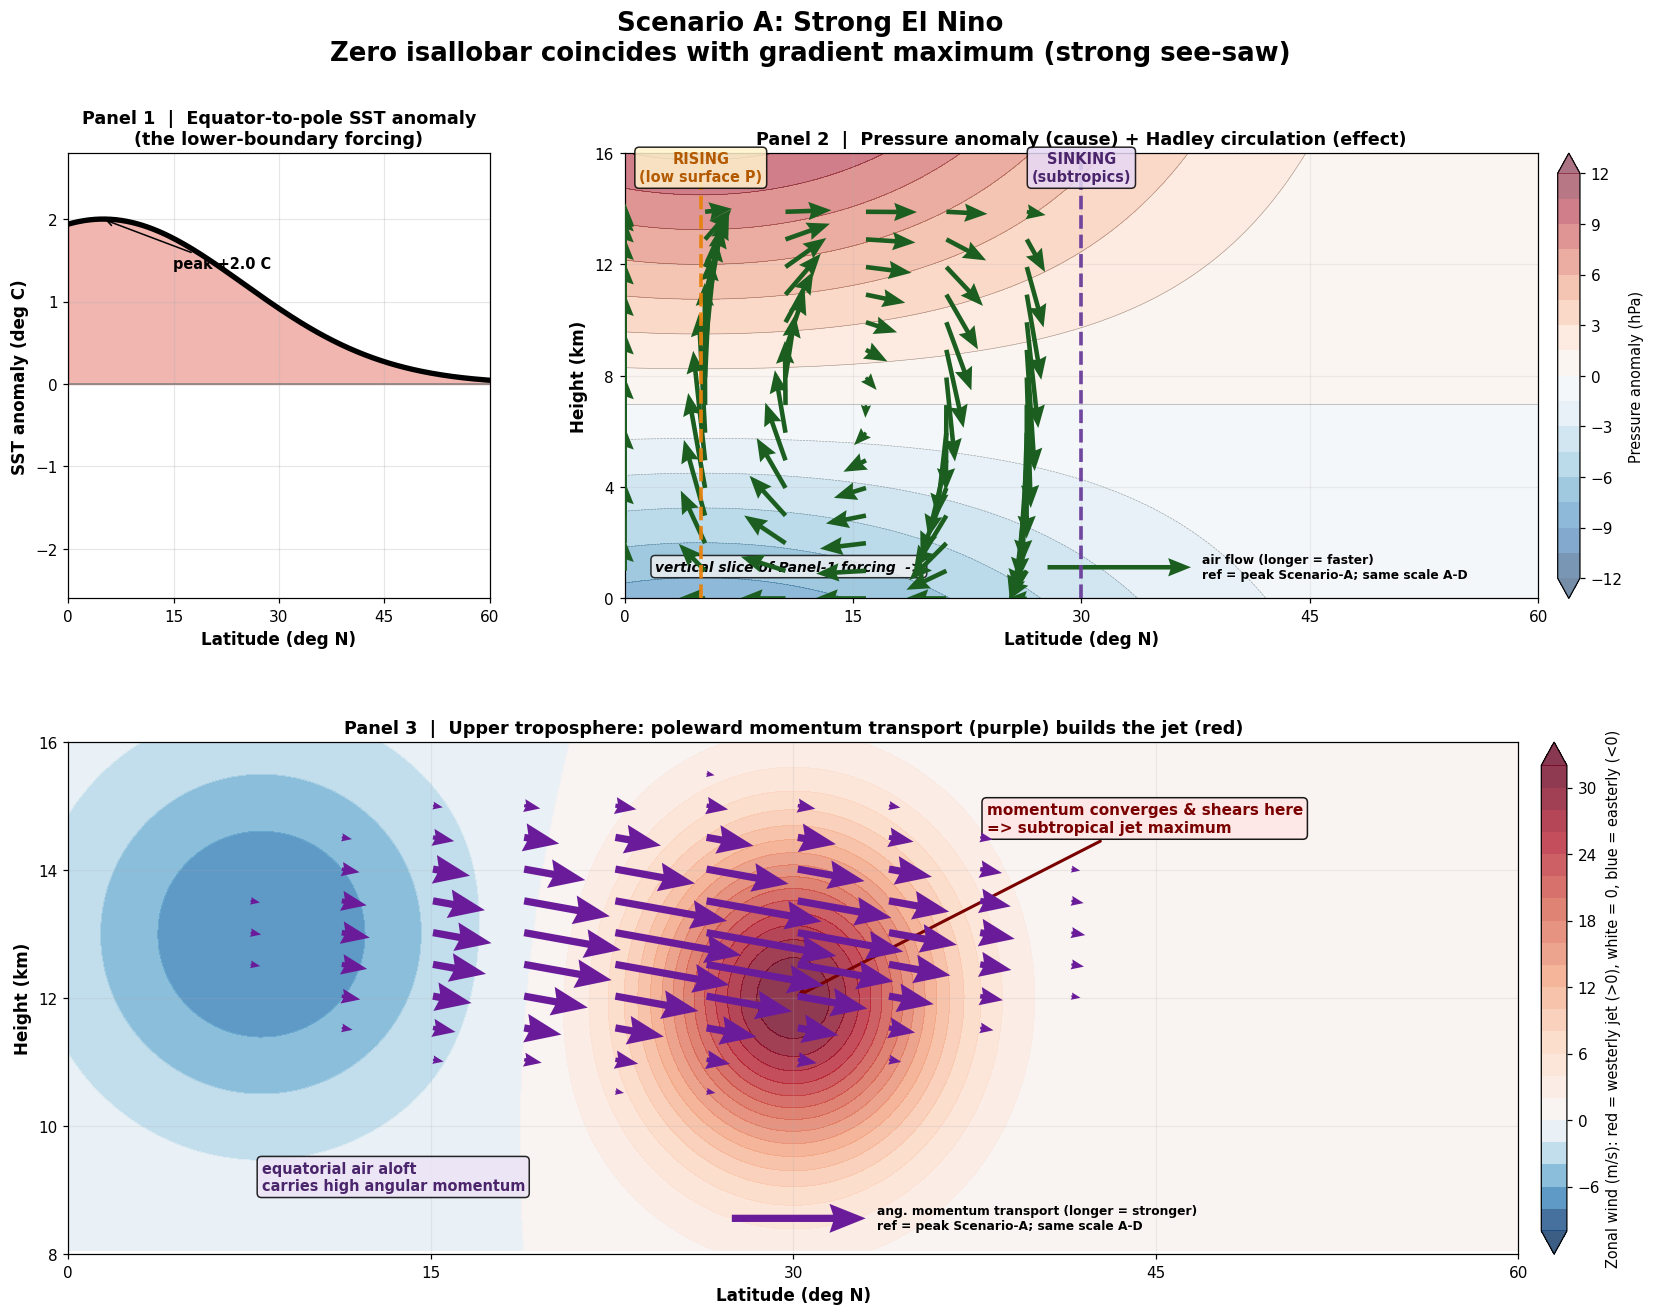

In [21]:
plot_scenario("A")

---
## 7 - Scenario B : Basin-Wide Warm Offset  (the key insight)

**Setup.** The entire basin is warm ($+2.5^\circ$C) - *warmer than Scenario A* - but the anomaly is **uniform**: no meridional gradient. This is the "global bias overrides the see-saw, no crossing" case.

**What to look for:**
- **Panel 1** - a flat line high above zero. Lots of warmth, zero structure.
- **Panel 2** - the punchline. Because SST has no latitude variation, the pressure-anomaly contours are **perfectly horizontal**. A horizontal contour field has **no horizontal gradient**, so there is nothing to push the air: the circulation arrows all but vanish. (The red callout box marks this explicitly.)
- **Panel 3** - with no overturning to pump momentum poleward, the purple arrows are stubs and the jet shading is barely tinted. The jet is not driven from its climatological state.

**Reading.** **It is the gradient, not the magnitude, that drives the teleconnection.** A uniform warm offset - however large - defeats the see-saw entirely. This is why B's teleconnection is *weaker than even the La Nina cases* (C and D): those at least possess a gradient to work with. The winter is **VARIABLE** - the jet is unpinned, free to wander, because no organized forcing constrains it.

> This scenario is the entire reason the four-scenario (A/B/C/D) comparison exists. If a reader leaves with one idea, it should be this one.

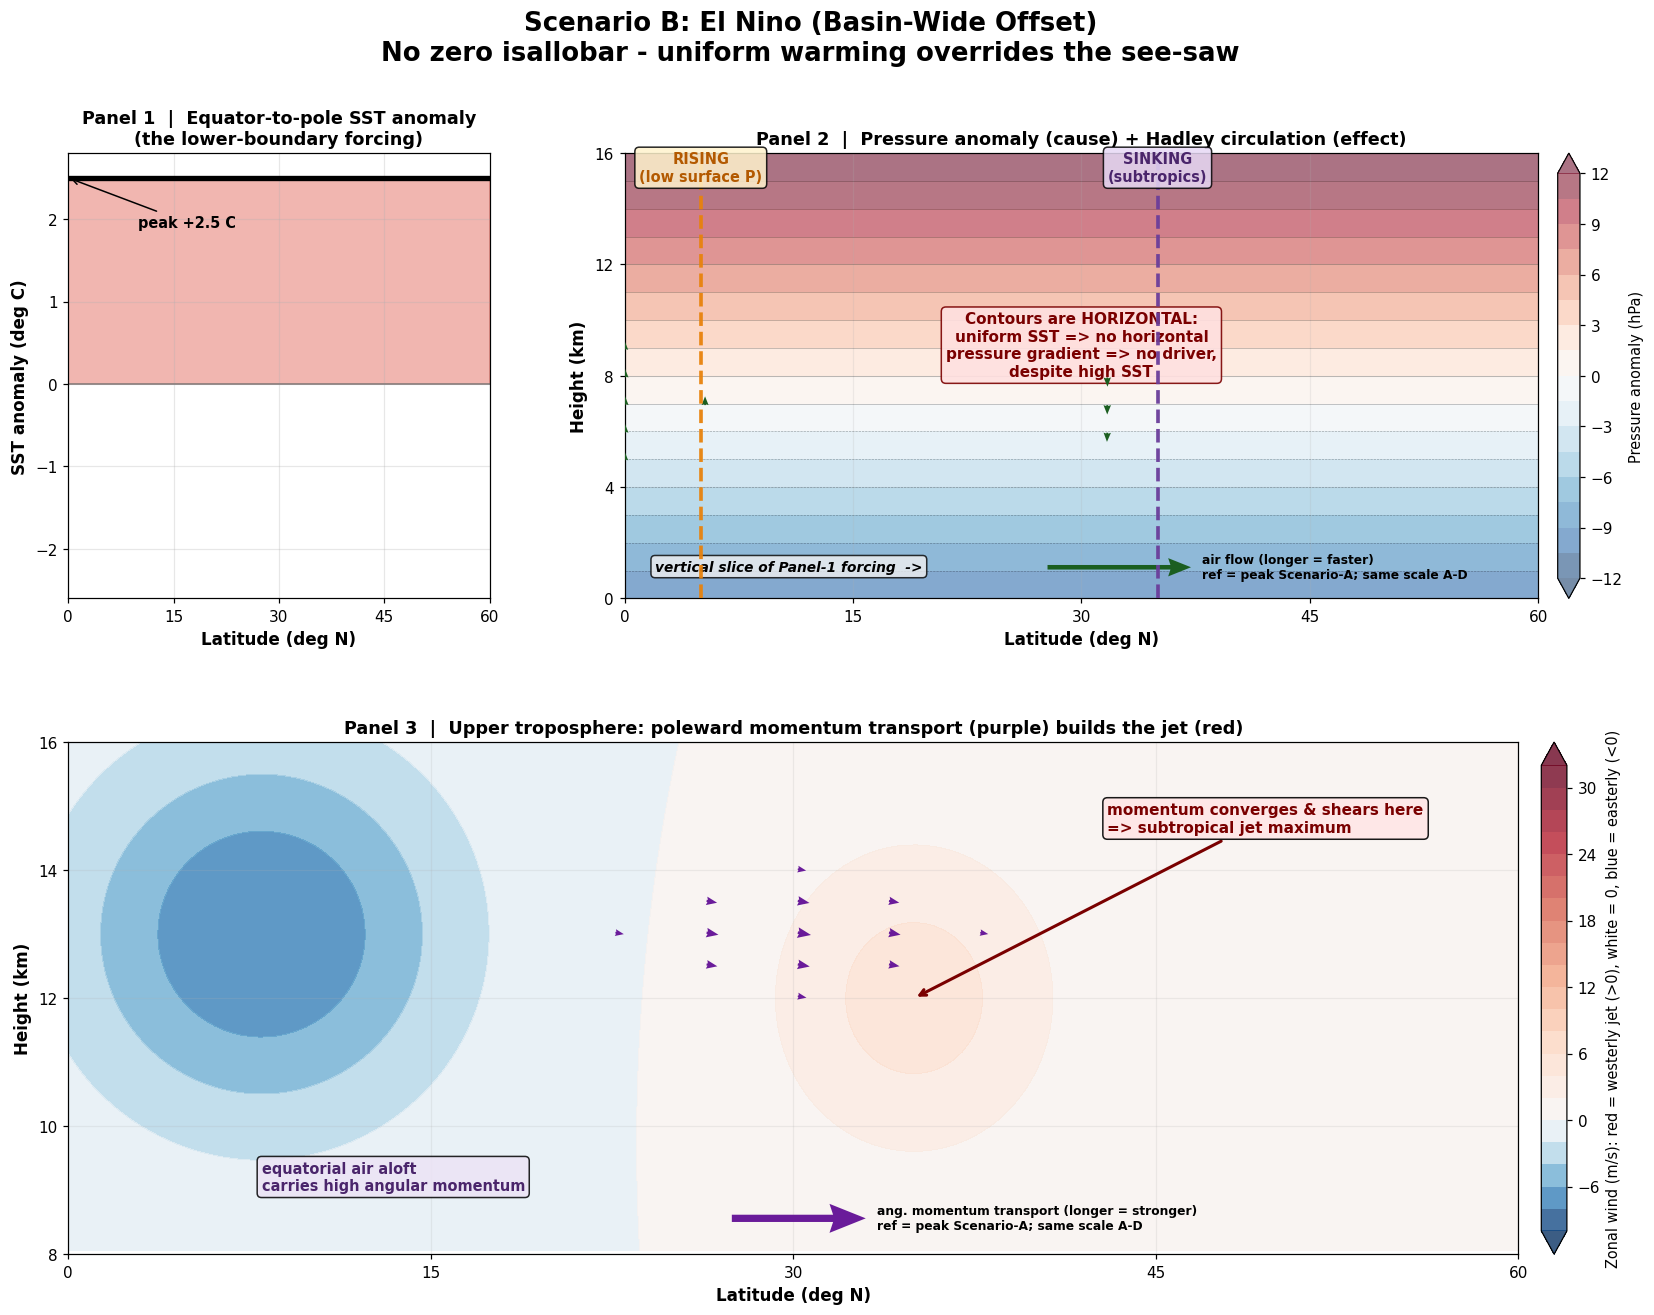

In [22]:
plot_scenario("B")

---
## 8 - Scenario C : Cold La Nina, node displaced east

**Setup.** A cold equatorial anomaly ($-1.8^\circ$C) with a gradient - a canonical La Nina, with the pressure node shifted east so the effective gradient is weak.

**What to look for:**
- **Panel 1** - the profile dips *below* zero in the tropics (blue fill), recovering toward the mid-latitudes.
- **Panel 2** - the sign flips relative to El Nino. A cold column means a *high* surface-pressure anomaly at the equator (red near the surface) and a *low* anomaly aloft. This **opposes** the climatological rising, so the cell is weak; the rising branch is annotated "weak rising (high surface P)."
- **Panel 3** - reduced poleward momentum transport (shorter arrows) feeds a noticeably *paler* jet than Scenario A.

**Reading.** La Nina suppresses the Hadley overturning, the poleward momentum flux weakens, and the jet is weak and less organized: a **LOW-INDEX winter**.

*Honest simplification:* a fully rigorous treatment would render the La Nina anomaly circulation as a weak **reversed** cell. Here it is drawn as a *weakened thermally-direct* cell (the climatological cell minus the La Nina suppression), which keeps the four panels visually parallel while preserving the key point - weak overturning, weak jet. The sign of the *pressure* anomaly is shown faithfully, so the forcing direction is not obscured.

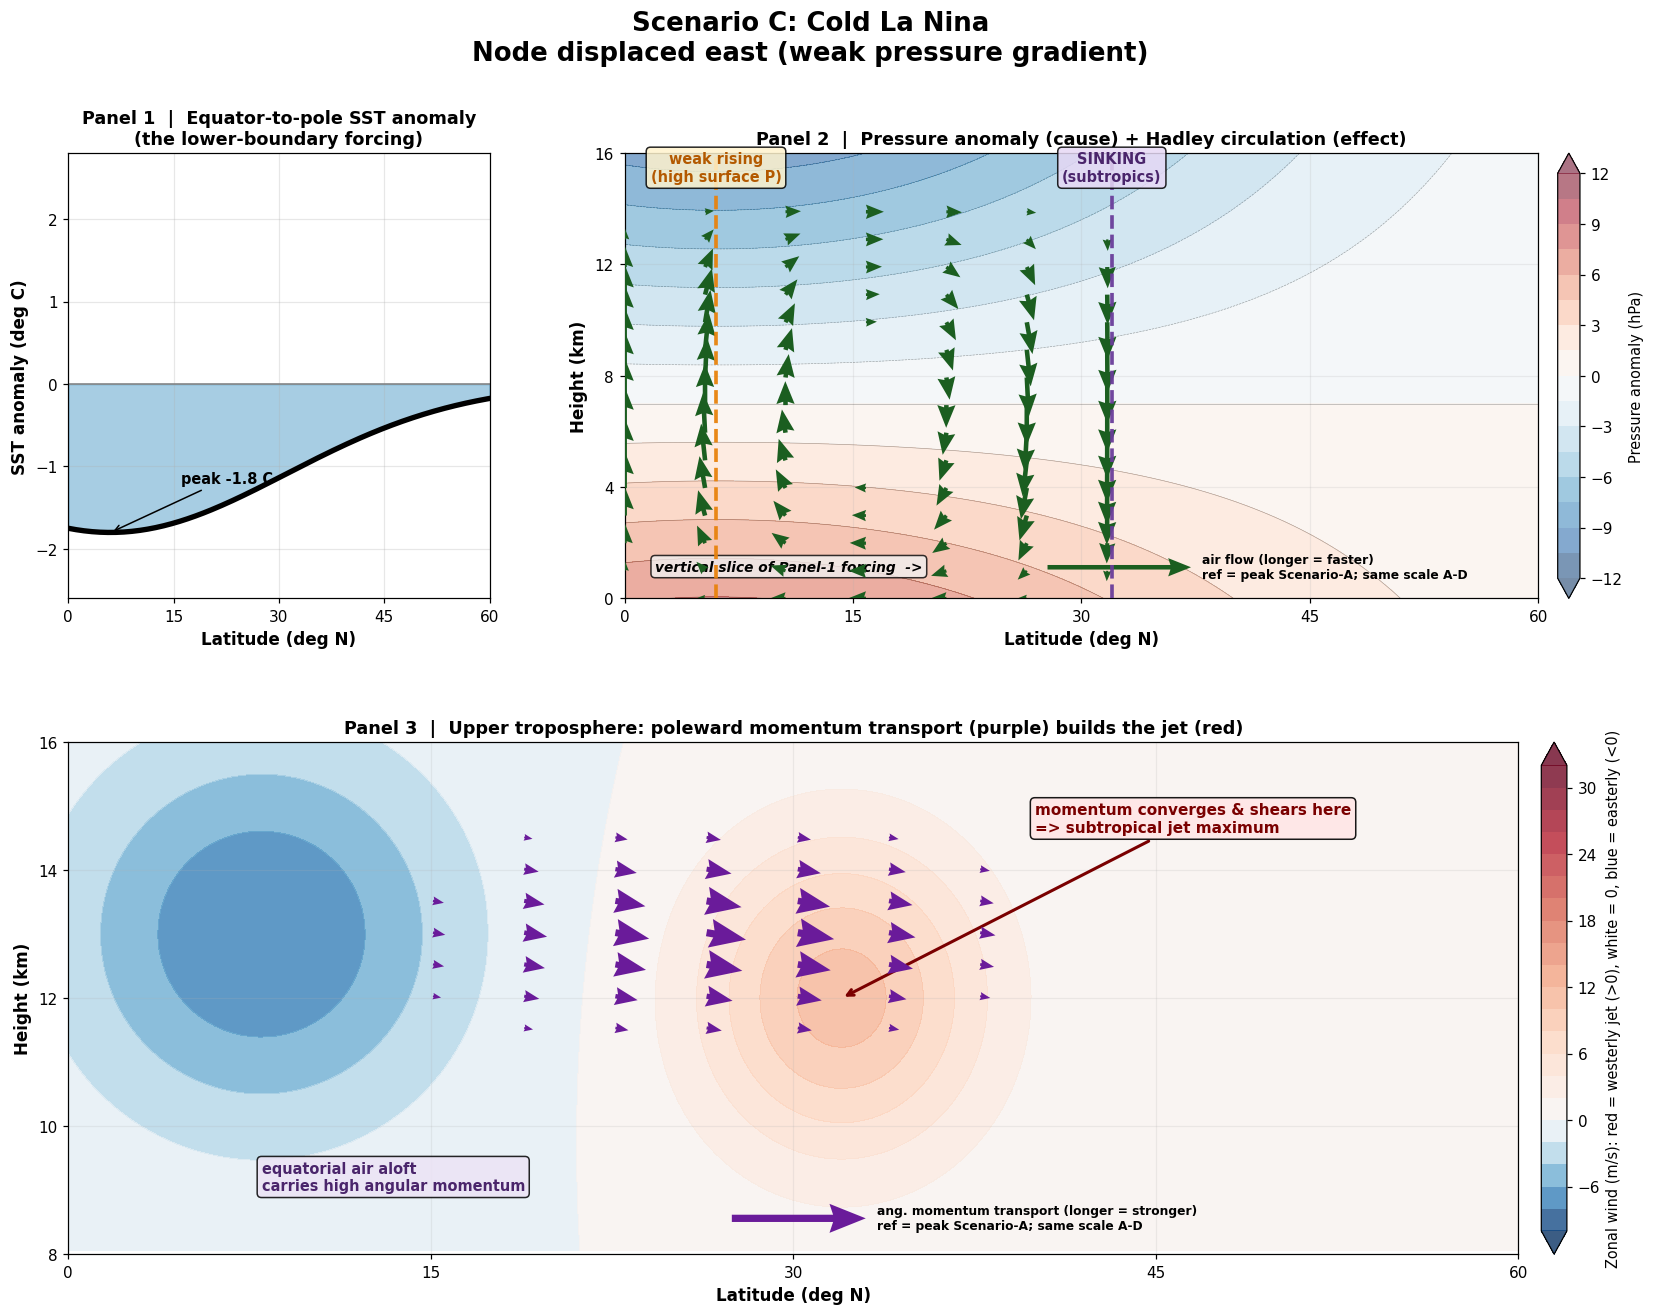

In [23]:
plot_scenario("C")

---
## 9 - Scenario D : Cold La Nina, node displaced west  (spatial disruption)

**Setup.** The strongest cold anomaly ($-2.0^\circ$C), the narrowest cell (descent pulled equatorward to $28^\circ$N), and the node displaced *west* - a spatially disrupted La Nina.

**What to look for:**
- **Panel 1** - the deepest cold trough of the four cases.
- **Panel 2** - flipped pressure (high surface anomaly at the equator), an even weaker and more compressed cell than C, with the sinking branch dragged in toward $28^\circ$N.
- **Panel 3** - the shortest purple arrows and the **palest jet** in the whole atlas.

**Reading.** The combination of suppression (cold) and spatial disruption (displaced node, compressed cell) yields the weakest, most fragmented response: a **LOW-INDEX, chaotic winter**. The jet is at its weakest and would be expected to meander and block rather than hold a steady, zonal course.

*Refinement worth flagging:* to make the "disruption" idea fully literal, a future version could split D's overturning into two competing partial cells and draw an explicitly wavy/fragmented jet line. Both were deferred pending this first look (see the closing notes).

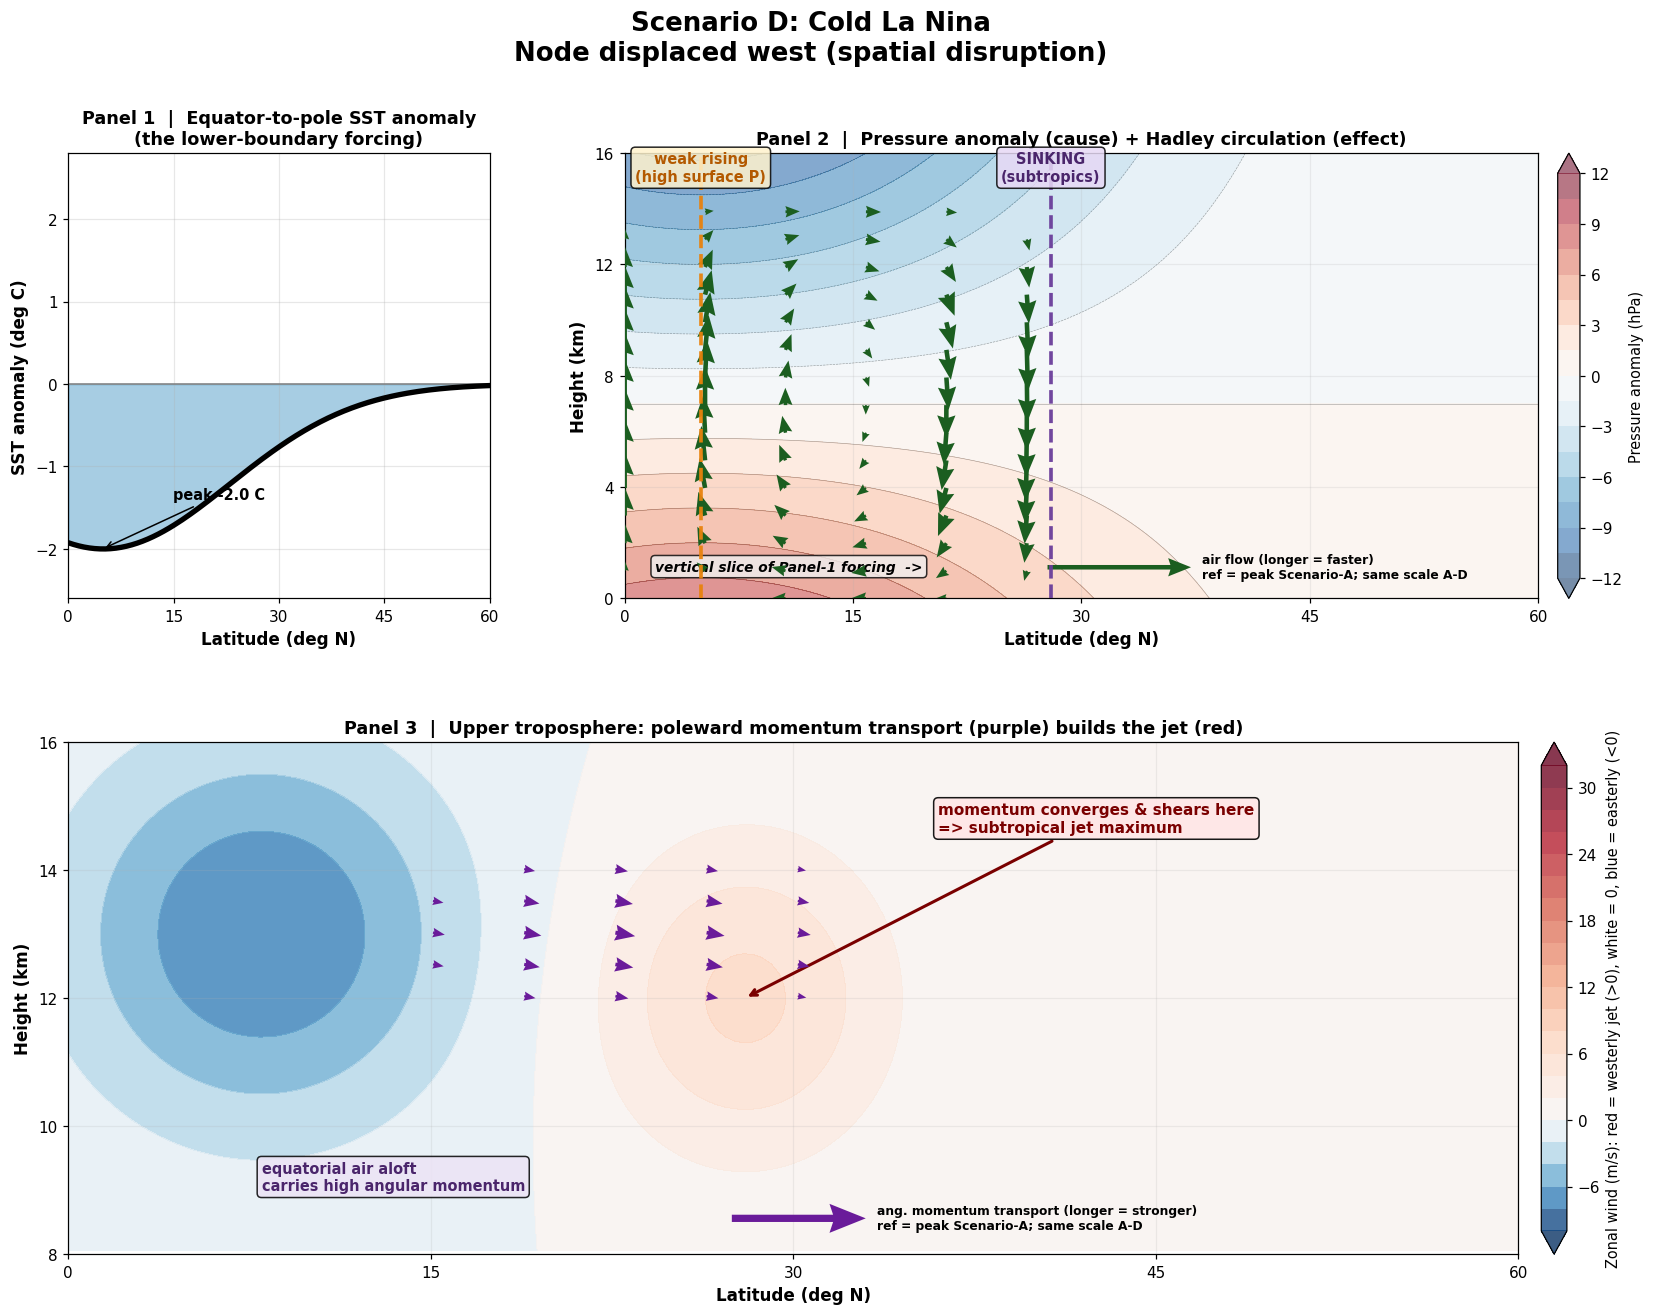

In [24]:
plot_scenario("D")

## A note on scope

This atlas is a deliberately idealized diagnostic, not a GCM. Several "more realistic"
embellishments were considered and rejected on principle: rendering the descent branch
with reanalysis-like sharpness, drawing wavy/meandering jet lines for the disrupted La Nina
cases, or splitting Scenario D into competing Hadley cells. Each would depict structure the
underlying axisymmetric model does not actually produce — eddies, meanders, and multi-cell
topology are interpretations attached to the weak-jet cases, not outputs of the streamfunction.
Drawing them as if the model generated them would overstate the model's fidelity, so they are
left to the prose.

One genuinely thesis-aligned extension remains open: overlaying horizontal pressure-gradient
(∂P/∂φ) vectors on Panel 2 to make the A-vs-B contrast quantitative — arrows present under
the El Nino gradient, absent under the uniform warm offset. The current figures already carry
this point via the horizontal-contour callout in B; the vector overlay would reinforce rather
than add. It is the one refinement worth revisiting if the gradient contrast ever needs to hit harder.

---
## 10 - Reading the four together, and what this is (and is not)

### The comparison, in one line each
- **A (strong El Nino)** - sharp gradient -> vigorous Hadley -> intense jet -> **HIGH index**. The yardstick.
- **B (basin-wide warm)** - warmest of all, *no* gradient -> *no* driver -> **VARIABLE**. Gradient beats magnitude.
- **C (La Nina, node E)** - cold, sign-flipped, weak -> **LOW index**.
- **D (La Nina, node W)** - cold + disrupted -> **LOW index, chaotic**. The weakest jet.

The strength ordering of the teleconnection is **B < D < C < A**. That B (an El Nino-flavored state) sits *below* the La Nina cases is the deliberate surprise: a basin-wide warm offset removes the see-saw, whereas La Nina at least supplies a gradient.

### Every simplification, stated plainly
1. **North-south slice of an east-west phenomenon.** The Bjerknes see-saw is zonal (Walker); these are meridional (Hadley) cross-sections. We trace the *downstream* tropics-to-jet teleconnection, folding the east-west node position into a single "how strong is the overturning" question.
2. **Anomalies, not absolutes.** All fields are departures from ENSO-neutral. El Nino's negative surface-pressure anomaly *enhances* the cell; La Nina's positive anomaly *weakens* it; uniform warming contributes *no* gradient.
3. **Absolute angular momentum vs. relative wind.** The $M = u + \Omega a\cos\phi$ equation mixes two reference frames: $\Omega a\cos\phi$ is the ground's eastward speed (in an inertial frame), while $u$ is wind relative to the ground. At the equator, even air at rest relative to the ground carries huge eastward angular momentum because the ground itself is moving east at ~465 m/s. As the Hadley upper branch carries this air poleward, conservation of $M$ converts that equatorial "free" eastward motion into an increasingly strong **relative eastward wind** (a westerly jet). The **surface branch is easterly** (trade winds, because air lags behind the faster-spinning equator); the **upper branch is westerly** (the subtropical jet, because air outruns the slowly-spinning high latitudes). Same air, two different winds, one conserved quantity $M$.
4. **Vertical motion exaggerated (~6x)** in Panel 2 so the overturning is legible in the arrows; true $w \sim \mathrm{cm\,s^{-1}}$ vs horizontal $\sim \mathrm{m\,s^{-1}}$.
5. **Arrows encode magnitude by length, at fixed scale.** Panel 2's green arrows show Hadley air-flow speed; Panel 3's purple arrows show angular-momentum-transport magnitude. In both, *length* (not thickness) encodes magnitude, and the reference arrow is fixed to Scenario A — so an arrow of given length means the same thing in every scenario, and B's collapsed flow reads as genuinely short. The jet color scale (Panel 3) is centered on zero but asymmetric (the westerly maximum far exceeds the tropical easterlies).
6. **La Nina drawn as a weakened-direct cell** rather than a fully reversed one, to keep the four panels parallel; the pressure-anomaly sign is shown faithfully.
7. **Jet pinned to the descent latitude; planar geometry.** The subtropical jet is centered *at* the Hadley descent latitude — the clean angular-momentum-conserving (Held–Hou) limit — whereas real jets, driven partly by transient eddies, can sit a few degrees poleward of the cell edge. Mass conservation is also exact only in the planar approximation; the spherical cos φ weighting is omitted. Both keep the figures readable and are detailed where each first appears.